# Image Compression using Modulo-Compressive Sensing

## Importing Libraries and Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from optimization.milp import solve_modulo_cs_milp

## Data Exploration

In [2]:
# load csv data to a numpy array
# train_data = np.loadtxt('data/mnist_train.csv', delimiter=',')
test_data = np.loadtxt('data/mnist_test.csv', delimiter=',')

In [3]:
test_data.shape

(10000, 785)

## Generating CS Matrix

In [5]:
def generate_CS_matrix(M:int, N:int=785):
    # Generate N vectors of dimension M from a standard Gaussian distribution
    A = np.array([np.random.randn(M) for _ in range(N)]).T
    # normalizing each column of A to a unit norm
    A = A / np.expand_dims(np.linalg.norm(A, ord=2, axis=1), axis=1)

    return A

## Generating Measurements

In [6]:
def generate_measurements(image_data: np.ndarray, num_measurements: int) -> tuple[np.ndarray, np.ndarray]:
    """
        Generate modulo measurements y = [[Ax]], where [[]] denotes the fractional parts of the elements of the vector Ax
        
        Parameters:
            - image_data: np.ndarray flattened vector of the image pixel values
            - num_measurements: int number of samples to be acquired of the 'densified' sparse image

        Returns:
            - np.ndarray: acquired samples y
            - np.ndarray: 2D compressed-sensing matrix    
    """
    
    num_pixels = len(image_data)
    # generating a normalized Gaussian-distributed Compressed Sensing Matrix
    A = generate_CS_matrix(M=num_measurements, N=num_pixels) # M < N
    # acquiring dense modulo samples from the sparse image vector
    y_dense = A @ image_data
    y = y_dense - np.floor(y_dense)

    return y, A

## Sparse Image Recovery

In [36]:
image_idx = np.floor(np.random.rand()*10000).astype('int')
image = test_data[image_idx,:]
image_idx

np.int64(7622)

In [37]:
y, A = generate_measurements(image_data=image, num_measurements=250)
z = A @ image

In [38]:
np.min(z), np.max(z)

(np.float64(-221.59346263556873), np.float64(187.81573799447534))

In [41]:
A.shape

(250, 785)

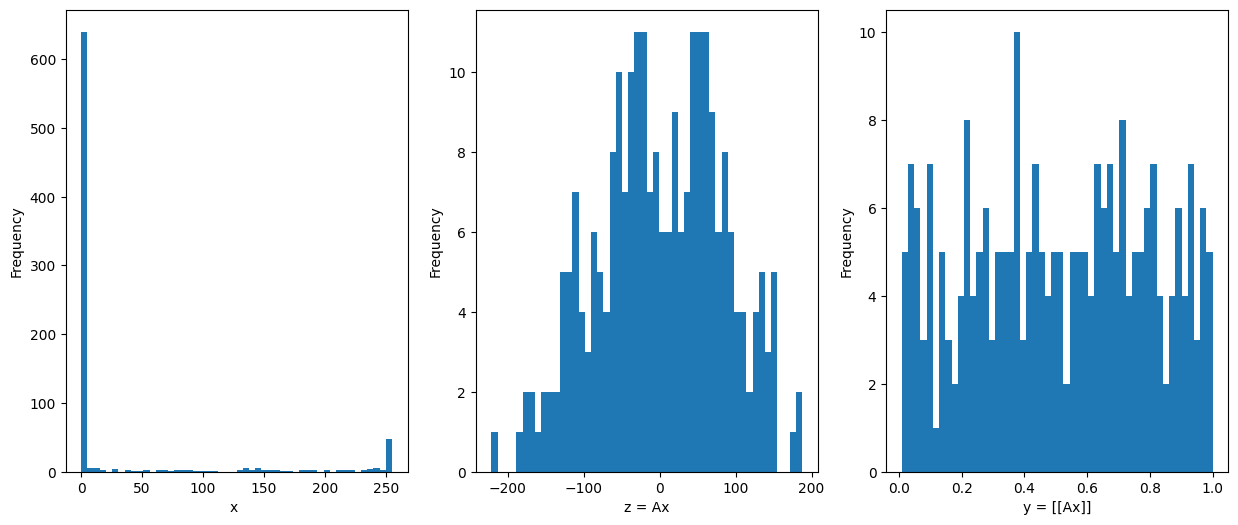

In [39]:
# plotting the distribution of measurements
plt.figure(figsize=(15, 6))

plt.subplot(1,3,1)
plt.hist(image, bins=50)
plt.xlabel('x ')
plt.ylabel('Frequency')

plt.subplot(1,3,2)
plt.hist(z, bins=50)
plt.xlabel('z = Ax')
plt.ylabel('Frequency')

plt.subplot(1,3,3)
plt.hist(y, bins=50)
plt.xlabel('y = [[Ax]]')
plt.ylabel('Frequency')

plt.tight_layout
plt.show()

### MILP

In [40]:
# x_reconst, integer_part, res = solve_modulo_cs_milp(A, y, v_bound=750)